# Modelos y Simulación - Trabajo Práctico 2

## 1) Ensayo con Varianza conocida (Z-test)

Cuándo se usa?
- Cuando se quiere probar una hipótesis sobre una media
- Cuando se conoce la desviación estándar poblacional (σ) o la varianza poblacional ($σ^2$)
- Cuando el tamaño de la muestra es grande (n>=30)

ESTADÍSTICO Z:
$Z = \frac{\bar{x}-μ_0}{σ/\sqrt{n}}$

$\bar{x}$: media muestral

$μ_0$: valor hipotético H0

$σ$: desviación estándar **poblacional**

n: tamaño de la muestra

## Ejercicio 1: Control de calidad industrial

Una empresa manufacturera de componentes electrónicos ha estado produciendo bombillas LED durante los últimos 5 años. Durante este período, han mantenido registros detallados de la duración de sus productos y han establecido que sus bombillas tienen una vida útil promedio de 1000hs.

Debido a la naturaleza de su proceso de producción masiva y los controles históricos, saben que la desviación estándar de la duración es consistentemente de 12hs, sin importar las variaciones menores en el proceso.

Recientemente, implementaron una nueva tecnología en su línea de producción que promete mejorar la eficiencia. Sin embargo, el departamento de control de calidad está preocupado de que esta nueva tecnología pueda estar afectando negativamente la durabilidad de las bombillas.

Para investigar esto, el equipo de calidad seleccionó aleatoriamente 64 bombillas del primer lote producido con la nueva tecnología y las sometió a pruebas de durabilidad. Los resultados mostraron que estas bombillas tuvieron una duración promedio de 980hs.

Objetivo: Determinar si existe evidencia estadística suficiente para concluir que la nueva tecnología ha reducido la duración promedio de las bombillas. La gerencia está dispuesta a aceptar un riesgo del 5% de tomar una decisión errónea.

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, t
import warnings
warnings.filterwarnings('ignore')

# Configuración para gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

### DATOS DEL PROBLEMA

In [2]:
# Datos del problema
mu_0 = 1000      # Media poblacional bajo H0
sigma = 120      # Desviación estándar poblacional (conocida)
n = 64           # Tamaño de la muestra
x_bar = 980      # Media muestral
alpha = 0.05     # Nivel de significancia

print(f"\n📊 DATOS EXTRAÍDOS DEL CONTEXTO:")
print(f"   • Duración promedio histórica (μ₀): {mu_0} horas")
print(f"   • Desviación estándar conocida (σ): {sigma} horas")
print(f"   • Tamaño de muestra (n): {n} bombillas")
print(f"   • Duración promedio muestral (x̄): {x_bar} horas")
print(f"   • Nivel de significancia (α): {alpha}")


📊 DATOS EXTRAÍDOS DEL CONTEXTO:
   • Duración promedio histórica (μ₀): 1000 horas
   • Desviación estándar conocida (σ): 120 horas
   • Tamaño de muestra (n): 64 bombillas
   • Duración promedio muestral (x̄): 980 horas
   • Nivel de significancia (α): 0.05


### DESARROLLO DE LA SOLUCIÓN

1. FORMULACIÓN DE HIPÓTESIS:

   H₀: μ = 1000 (la nueva tecnología no afecta la duración)

   H₁: μ < 1000 (la nueva tecnología reduce la duración)

   📝 Nota: Es una prueba unilateral izquierda

2. SELECCIÓN DEL ESTADÍSTICO:

   ✅ Varianza poblacional conocida → Usamos Z-test

   ✅ Muestra grande (n=64 > 30) → Distribución normal aplicable

3. CÁLCULO DEL ESTADÍSTICO Z:

   Z = (x̄ - μ₀) / (σ / √n)

4. CRITERIOS DE DECISIÓN:

   Valor crítico (Z₀.₀₅)
   
   Estadístico calculado (Z)
   
   P-value

5. DECISIÓN ESTADÍSTICA

🎯 CONCLUSIÓN FINAL


------------------------------------
Funciones:
- Prueba unilateral izquierda: (Rechazar H0 si Z_obs <= z_crit)

  z_crit = stats.norm.ppf(alpha)   

- Prueba unilateral derecha: (Rechazar H0 si Z_obs >= z_crit)

  z_crit = stats.norm.ppf(1 - alpha)
  
  z_crit = stats.norm.isf(alpha)

- Prueba bilateral: (Rechazar H0 si |Z_obs| >= z_crit)

  z_crit = stats.norm.ppf(1 - alpha/2)
  
  z_crit = stats.norm.isf(alpha/2)

In [3]:
# Paso 3: Cálculo del estadístico Z
z_stat = (x_bar - mu_0) / (sigma / np.sqrt(n))
print(f"\n3️⃣ CÁLCULO DEL ESTADÍSTICO Z:")
print(f"   Z = (x̄ - μ₀) / (σ / √n)")
print(f"   Z = ({x_bar} - {mu_0}) / ({sigma} / √{n})")
print(f"   Z = {x_bar - mu_0} / {sigma / np.sqrt(n):.2f}")
print(f"   Z = {z_stat:.4f}")


3️⃣ CÁLCULO DEL ESTADÍSTICO Z:
   Z = (x̄ - μ₀) / (σ / √n)
   Z = (980 - 1000) / (120 / √64)
   Z = -20 / 15.00
   Z = -1.3333


In [4]:
# Paso 4: Determinación del valor crítico y p-valor
z_critical = stats.norm.ppf(alpha)  # Para prueba unilateral izquierda
p_value = stats.norm.cdf(z_stat)

print(f"\n4️⃣ CRITERIOS DE DECISIÓN:")
print(f"   Valor crítico (Z₀.₀₅): {z_critical:.4f}")
print(f"   Estadístico calculado (Z): {z_stat:.4f}")
print(f"   P-valor: {p_value:.6f}")


4️⃣ CRITERIOS DE DECISIÓN:
   Valor crítico (Z₀.₀₅): -1.6449
   Estadístico calculado (Z): -1.3333
   P-valor: 0.091211


In [5]:
# Paso 5: Decisión
print(f"\n5️⃣ DECISIÓN ESTADÍSTICA:")
if z_stat < z_critical:
    decision = "RECHAZAR H₀"
    conclusion = "SÍ hay evidencia estadística de reducción en la duración"
else:
    decision = "NO RECHAZAR H₀"
    conclusion = "NO hay evidencia estadística de reducción en la duración"

print(f"   Como Z = {z_stat:.4f} {'<' if z_stat < z_critical else '≥'} {z_critical:.4f}")
print(f"   Decisión: {decision}")
print(f"   P-valor = {p_value:.6f} {'<' if p_value < alpha else '≥'} α = {alpha}")

print(f"\n🎯 CONCLUSIÓN FINAL:")
print(f"   {conclusion}")
print(f"   Con un nivel de confianza del 95%, podemos afirmar que la nueva")
print(f"   tecnología {'SÍ' if z_stat < z_critical else 'NO'} ha reducido significativamente la duración de las bombillas.")


5️⃣ DECISIÓN ESTADÍSTICA:
   Como Z = -1.3333 ≥ -1.6449
   Decisión: NO RECHAZAR H₀
   P-valor = 0.091211 ≥ α = 0.05

🎯 CONCLUSIÓN FINAL:
   NO hay evidencia estadística de reducción en la duración
   Con un nivel de confianza del 95%, podemos afirmar que la nueva
   tecnología NO ha reducido significativamente la duración de las bombillas.


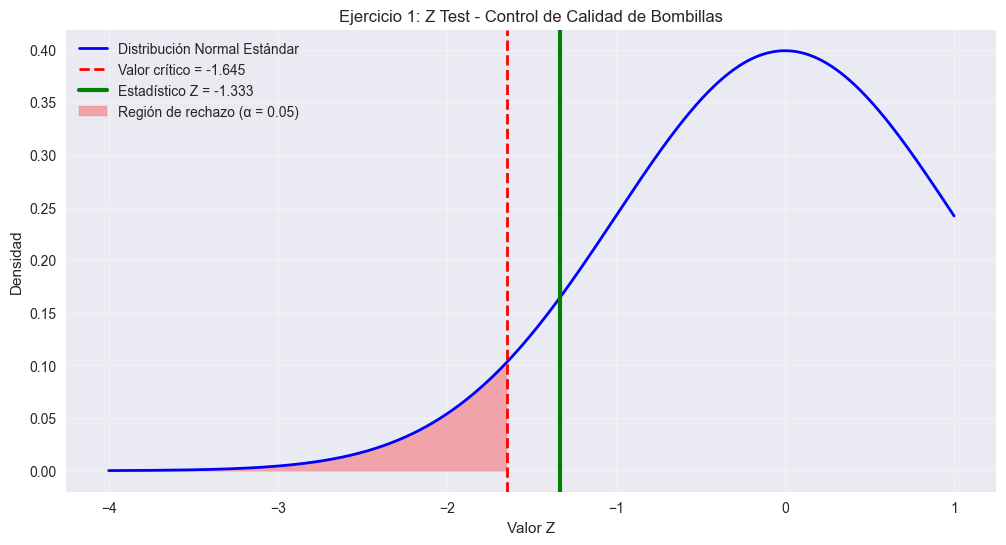

In [6]:
# Visualización
plt.figure(figsize=(12, 6))
x = np.linspace(-4, 1, 1000)
y = stats.norm.pdf(x, 0, 1)

plt.plot(x, y, 'b-', linewidth=2, label='Distribución Normal Estándar')
plt.axvline(z_critical, color='red', linestyle='--', linewidth=2, label=f'Valor crítico = {z_critical:.3f}')
plt.axvline(z_stat, color='green', linestyle='-', linewidth=3, label=f'Estadístico Z = {z_stat:.3f}')

# Sombrear región de rechazo
x_fill = x[x <= z_critical]
y_fill = stats.norm.pdf(x_fill, 0, 1)
plt.fill_between(x_fill, y_fill, alpha=0.3, color='red', label=f'Región de rechazo (α = {alpha})')

plt.xlabel('Valor Z')
plt.ylabel('Densidad')
plt.title('Ejercicio 1: Z Test - Control de Calidad de Bombillas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2) Ensayo con Varianza desconocida (t de Student)

Cuándo se usa?
- Cuando no se conoce la varianza poblacional ($σ^2$)
- Cuando el tamaño de la muestra es chico (n<30)

Se usa la desviación estándar muestral (s) y el estadístico t de student con n-1 grados de libertad.

ESTADÍSTICO t de Student:
$t = \frac{\bar{x}-μ_0}{s/\sqrt{n}}$

$\bar{x}$: media muestral

$μ_0$: valor hipotético H0

$σ$: desviación estándar **muestral**

n: tamaño de la muestra

## Ejercicio 2: Efectividad de terapia psicológica

En el Centro de Bienestar Psicológico de una universidad, la Dra María Gonzalez ha estado investigando métodos alternativos para ayudar a los estudiantes a manejar el estrés acadámico. El semestre pasado, implementó un programa piloto de meditación de 8 semanas de duración.

Para evaluar la efectividad del programa, seleccionó una muestra de 12 estudiantes voluntarios que reportaron niveles altos de estrés académico. Utilizó la Escala de estrés percibido (PSS-10), que va de 0 a 100 puntos, donde puntuaciones más altas indican mayor nivel de estrés.

La evaluación se realizó en dos momentos: una semana antes de iniciar el programa y una semana después de completarlo. Como es común en estudios piloto, no se disponía de información previa sobre la variabilidad esperada en las diferencias de puntajes.

Los cambios observados en cada participante (Después - Antes) fueron los siguientes:

Participante 1: -5 puntos

Participante 2: -8 puntos

Participante 3: -2 puntos

Participante 4: -10 puntos

Participante 5: -6 puntos

Participante 6: -4 puntos

Participante 7: -7 puntos

Participante 8: -3 puntos

Participante 9: -9 puntos

Participante 10: -5 puntos

Participante 11: -6 puntos

Participante 12: -8 puntos

NOTA: los valores negativos indican reducción de estrés.

Objetivo: determinar si existe evidencia estadística sólida de que el programa de meditación reduce significativamente los niveles de estrés. Dado que se trata de un estudio piloto que podría expandirse a toda la universidad, se busca ser muy conservadores y solo aceptar un 1% de riesgo de error.

In [7]:
# Datos del problema
diferencias = np.array([-5, -8, -2, -10, -6, -4, -7, -3, -9, -5, -6, -8])
n = len(diferencias)
alpha = 0.01
mu_0 = 0  # Hipótesis nula: no hay diferencia

print(f"\n📊 DATOS EXTRAÍDOS DEL CONTEXTO:")
print(f"   • Número de participantes (n): {n}")
print(f"   • Diferencias observadas: {diferencias}")
print(f"   • Nivel de significancia (α): {alpha}")
print(f"   • Hipótesis nula: μ_diferencias = 0 (no hay efecto)")


📊 DATOS EXTRAÍDOS DEL CONTEXTO:
   • Número de participantes (n): 12
   • Diferencias observadas: [ -5  -8  -2 -10  -6  -4  -7  -3  -9  -5  -6  -8]
   • Nivel de significancia (α): 0.01
   • Hipótesis nula: μ_diferencias = 0 (no hay efecto)


In [8]:
# Estadísticas descriptivas
x_bar = np.mean(diferencias)
s = np.std(diferencias, ddof=1)  # Desviación estándar muestral
df = n - 1

print(f"\n📈 ESTADÍSTICAS DESCRIPTIVAS:")
print(f"   • Media de diferencias (x̄): {x_bar:.3f}")
print(f"   • Desviación estándar muestral (s): {s:.3f}")
print(f"   • Grados de libertad (df): {df}")


📈 ESTADÍSTICAS DESCRIPTIVAS:
   • Media de diferencias (x̄): -6.083
   • Desviación estándar muestral (s): 2.429
   • Grados de libertad (df): 11


### DESARROLLO DE LA SOLUCIÓN

1. FORMULACIÓN DE HIPÓTESIS:

   H₀: μ_diferencias = 0 (el programa no reduce el estrés)

   H₁: μ_diferencias < 0 (el programa reduce el estrés)

   📝 Nota: Es una prueba unilateral izquierda

2. SELECCIÓN DEL ESTADÍSTICO:

   ❌ Varianza poblacional desconocida

   ✅ Muestra pequeña (n={n} < 30) → Usamos t de Student

3. CÁLCULO DEL ESTADÍSTICO Z:

   t = (x̄ - μ₀) / (s / √n)

4. CRITERIOS DE DECISIÓN:

   Valor crítico (t₀.₀₁)
   
   Estadístico calculado (t)
   
   P-value

5. DECISIÓN ESTADÍSTICA

🎯 CONCLUSIÓN FINAL

------------------------------------
Funciones:
- Prueba unilateral izquierda: (Rechazar H0 si T_obs <= t_crit)

  t_crit = stats.t.ppf(alpha, df)  

- Prueba unilateral derecha: (Rechazar H0 si T_obs >= t_crit)

  t_crit = stats.t.ppf(1 - alpha, df)
  
  t_crit = stats.t.isf(alpha, df)

- Prueba bilateral: (Rechazar H0 si |T_obs| >= t_crit)

  t_crit = stats.t.ppf(1 - alpha/2, df)
  
  z_crit = stats.t.isf(alpha/2, df)

df: grados de libertad

In [9]:
# Paso 3: Cálculo del estadístico t
t_stat = (x_bar - mu_0) / (s / np.sqrt(n))
print(f"\n3️⃣ CÁLCULO DEL ESTADÍSTICO t:")
print(f"   t = (x̄ - μ₀) / (s / √n)")
print(f"   t = ({x_bar:.3f} - {mu_0}) / ({s:.3f} / √{n})")
print(f"   t = {x_bar:.3f} / {s / np.sqrt(n):.3f}")
print(f"   t = {t_stat:.4f}")


3️⃣ CÁLCULO DEL ESTADÍSTICO t:
   t = (x̄ - μ₀) / (s / √n)
   t = (-6.083 - 0) / (2.429 / √12)
   t = -6.083 / 0.701
   t = -8.6746


In [10]:
# Paso 4: Determinación del valor crítico y p-valor
t_critical = stats.t.ppf(alpha, df)  # Para prueba unilateral izquierda
p_value = stats.t.cdf(t_stat, df)

print(f"\n4️⃣ CRITERIOS DE DECISIÓN:")
print(f"   Valor crítico (t₀.₀₁,{df}): {t_critical:.4f}")
print(f"   Estadístico calculado (t): {t_stat:.4f}")
print(f"   P-valor: {p_value:.6f}")


4️⃣ CRITERIOS DE DECISIÓN:
   Valor crítico (t₀.₀₁,11): -2.7181
   Estadístico calculado (t): -8.6746
   P-valor: 0.000002


In [11]:
# Paso 5: Decisión
print(f"\n5️⃣ DECISIÓN ESTADÍSTICA:")
if t_stat < t_critical:
    decision = "RECHAZAR H₀"
    conclusion = "SÍ hay evidencia estadística de reducción en el estrés"
else:
    decision = "NO RECHAZAR H₀"
    conclusion = "NO hay evidencia estadística de reducción en el estrés"

print(f"   Como t = {t_stat:.4f} {'<' if t_stat < t_critical else '≥'} {t_critical:.4f}")
print(f"   Decisión: {decision}")
print(f"   P-valor = {p_value:.6f} {'<' if p_value < alpha else '≥'} α = {alpha}")

print(f"\n🎯 CONCLUSIÓN FINAL:")
print(f"   {conclusion}")
print(f"   Con un nivel de confianza del 99%, {'SÍ' if t_stat < t_critical else 'NO'} podemos afirmar que")
print(f"   el programa de meditación reduce significativamente el estrés.")


5️⃣ DECISIÓN ESTADÍSTICA:
   Como t = -8.6746 < -2.7181
   Decisión: RECHAZAR H₀
   P-valor = 0.000002 < α = 0.01

🎯 CONCLUSIÓN FINAL:
   SÍ hay evidencia estadística de reducción en el estrés
   Con un nivel de confianza del 99%, SÍ podemos afirmar que
   el programa de meditación reduce significativamente el estrés.


In [12]:
# Verificación con scipy
t_stat_scipy, p_value_scipy = stats.ttest_1samp(diferencias, 0, alternative='less')
print(f"\n✅ VERIFICACIÓN CON SCIPY:")
print(f"   t-estadístico: {t_stat_scipy:.4f}")
print(f"   p-valor: {p_value_scipy:.6f}")


✅ VERIFICACIÓN CON SCIPY:
   t-estadístico: -8.6746
   p-valor: 0.000002


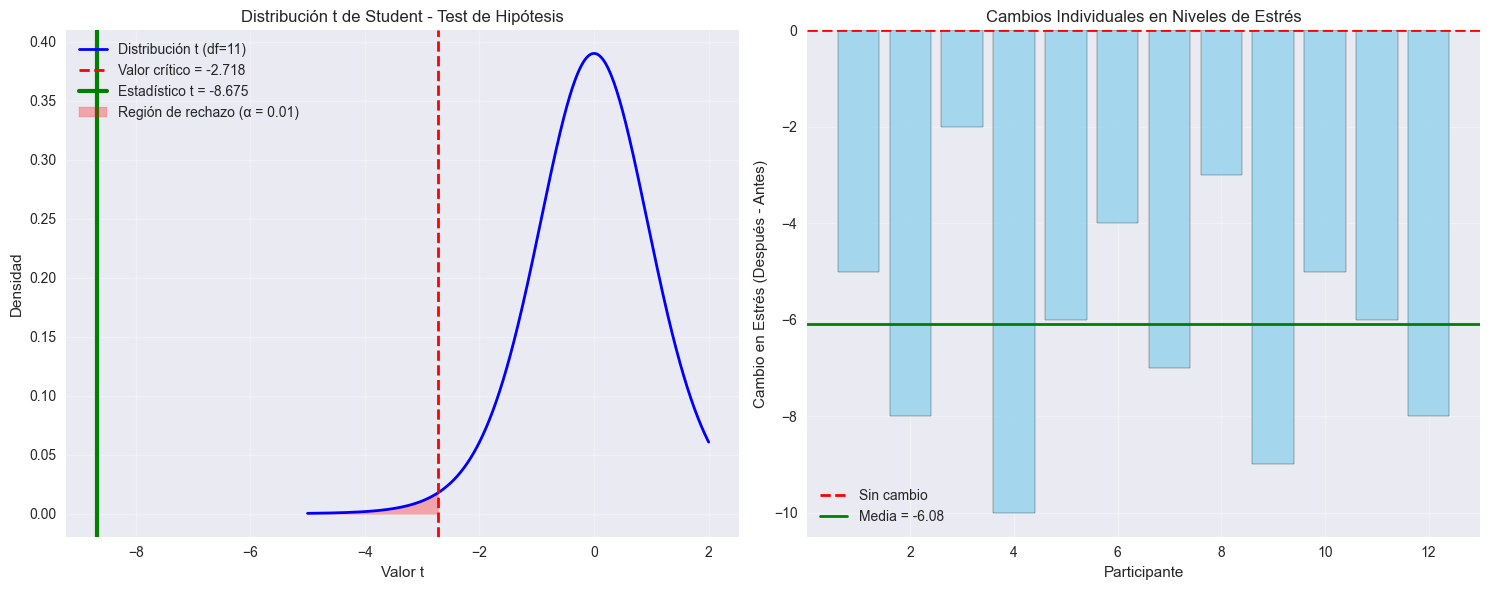

In [13]:
# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Distribución t con región de rechazo
x = np.linspace(-5, 2, 1000)
y = stats.t.pdf(x, df)

ax1.plot(x, y, 'b-', linewidth=2, label=f'Distribución t (df={df})')
ax1.axvline(t_critical, color='red', linestyle='--', linewidth=2, label=f'Valor crítico = {t_critical:.3f}')
ax1.axvline(t_stat, color='green', linestyle='-', linewidth=3, label=f'Estadístico t = {t_stat:.3f}')

x_fill = x[x <= t_critical]
y_fill = stats.t.pdf(x_fill, df)
ax1.fill_between(x_fill, y_fill, alpha=0.3, color='red', label=f'Región de rechazo (α = {alpha})')

ax1.set_xlabel('Valor t')
ax1.set_ylabel('Densidad')
ax1.set_title('Distribución t de Student - Test de Hipótesis')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Diferencias observadas
ax2.bar(range(1, n+1), diferencias, color='skyblue', alpha=0.7, edgecolor='black')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Sin cambio')
ax2.axhline(y=x_bar, color='green', linestyle='-', linewidth=2, label=f'Media = {x_bar:.2f}')
ax2.set_xlabel('Participante')
ax2.set_ylabel('Cambio en Estrés (Después - Antes)')
ax2.set_title('Cambios Individuales en Niveles de Estrés')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3) Cálculo del tamaño muestral

## Ejercicio 3: Diseño de estudio de inteligencia

El Instituto de Neurociencias Cognitivas ha recibido una importante subvención de investigación para estudiar el efecto de un programa de entrenamiento cognitivo en el coeficiente intelectual (CI).

Se necesita determinar cuántos participantes requerirá para obtener resultados científicamente válidos.

Basándonos en la literatura científica existente, sabemos que:
- Los tests de CI etsándar tienen una desviación estándar poblacional de 25 puntos
- Los estudios previos con programas similares han mostrado mejoras modestas pero consistentes
- Para que el programa sea considerado "clínicamente significativo", debe producir una mejora mínima de 10 puntos en el CI

El comité de ética y el consejo científico establecieron los siguientes requisitos estadísticos:
- El riesgo de error Tipo I (concluir falsamente que hay efecto) debe ser máximo 5%
- La potencia estadística (capacidad de detectar el efecto si realmente existe) debe ser al menos 85%

Además, el estudio debe ser diseñado como una comparación entre el grupo que recibe el entrenamiento versis un grupo de control, pero para este cálculo inicial, nos enfocaremos en determinar el tamaño necesario para una sola muestra.

Objetivo: calculas el tamaño muestral mínimo necesario para detectar una mejora de 10 puntos en el CI con los parámetros especificados También debemos proporcionar recomendaciones sobre cómo estos parámetros adectan el tamaño requerido.

In [14]:
# Parámetros del problema
delta = 10          # Diferencia mínima a detectar
sigma = 25          # Desviación estándar poblacional
alpha = 0.05        # Nivel de significancia
power = 0.85        # Potencia deseada (85%)
beta = 1 - power    # Probabilidad de error Tipo II

print(f"\n📊 PARÁMETROS EXTRAÍDOS DEL CONTEXTO:")
print(f"   • Diferencia mínima a detectar (δ): {delta} puntos")
print(f"   • Desviación estándar poblacional (σ): {sigma} puntos")
print(f"   • Nivel de significancia (α): {alpha}")
print(f"   • Potencia deseada (1-β): {power}")
print(f"   • Error Tipo II (β): {beta}")


📊 PARÁMETROS EXTRAÍDOS DEL CONTEXTO:
   • Diferencia mínima a detectar (δ): 10 puntos
   • Desviación estándar poblacional (σ): 25 puntos
   • Nivel de significancia (α): 0.05
   • Potencia deseada (1-β): 0.85
   • Error Tipo II (β): 0.15000000000000002


### DESARROLLO DE LA SOLUCIÓN

1. DETERMINACIÓN DE VALORES CRÍTICOS:

   - α (bilateral)
   
   - Potencia

2. FÓRMULA DEL TAMAÑO MUESTRAL:

  n = $\frac{(Z_{α/2}+Z_β) * σ^2}{δ^2}$

3. CÁLCULO

4. RESULTADO PRINCIPAL

5. ANÁLISIS DE SENSIBILIDAD

6. EFECTO DE LA POTENCIA

7. EFECTO DEL NIVEL DE SIGNIFICANCIA

In [15]:
# Paso 1: Valores críticos
z_alpha_2 = stats.norm.ppf(1 - alpha/2)  # Para prueba bilateral
z_beta = stats.norm.ppf(power)            # Para la potencia

print(f"\n1️⃣ DETERMINACIÓN DE VALORES CRÍTICOS:")
print(f"   Para α = {alpha} (bilateral): Z₀.₀₂₅ = {z_alpha_2:.4f}")
print(f"   Para potencia = {power}: Z₀.₈₅ = {z_beta:.4f}")


1️⃣ DETERMINACIÓN DE VALORES CRÍTICOS:
   Para α = 0.05 (bilateral): Z₀.₀₂₅ = 1.9600
   Para potencia = 0.85: Z₀.₈₅ = 1.0364


In [16]:
# Paso 2: Fórmula del tamaño muestral
print(f"\n2️⃣ FÓRMULA DEL TAMAÑO MUESTRAL:")
print(f"   n = (Z_{alpha/2} + Z_β)² × σ² / δ²")
print(f"   donde:")
print(f"   • Z_{alpha/2} = valor crítico para nivel de significancia")
print(f"   • Z_β = valor crítico para la potencia")
print(f"   • σ = desviación estándar poblacional")
print(f"   • δ = diferencia mínima a detectar")


2️⃣ FÓRMULA DEL TAMAÑO MUESTRAL:
   n = (Z_0.025 + Z_β)² × σ² / δ²
   donde:
   • Z_0.025 = valor crítico para nivel de significancia
   • Z_β = valor crítico para la potencia
   • σ = desviación estándar poblacional
   • δ = diferencia mínima a detectar


In [17]:
# Paso 3: Cálculo
numerador = (z_alpha_2 + z_beta)**2 * sigma**2
denominador = delta**2
n_calculated = numerador / denominador
n_required = int(np.ceil(n_calculated))

print(f"\n3️⃣ CÁLCULO PASO A PASO:")
print(f"   n = ({z_alpha_2:.4f} + {z_beta:.4f})² × {sigma}² / {delta}²")
print(f"   n = ({z_alpha_2 + z_beta:.4f})² × {sigma**2} / {delta**2}")
print(f"   n = {(z_alpha_2 + z_beta)**2:.4f} × {sigma**2} / {delta**2}")
print(f"   n = {numerador:.2f} / {denominador}")
print(f"   n = {n_calculated:.2f}")
print(f"   n ≈ {n_required} participantes (redondeando hacia arriba)")


3️⃣ CÁLCULO PASO A PASO:
   n = (1.9600 + 1.0364)² × 25² / 10²
   n = (2.9964)² × 625 / 100
   n = 8.9784 × 625 / 100
   n = 5611.50 / 100
   n = 56.11
   n ≈ 57 participantes (redondeando hacia arriba)


In [18]:
print(f"\n🎯 RESULTADO PRINCIPAL:")
print(f"   Se necesitan {n_required} participantes para detectar una mejora")
print(f"   de {delta} puntos con {power*100}% de potencia y α = {alpha}")


🎯 RESULTADO PRINCIPAL:
   Se necesitan 57 participantes para detectar una mejora
   de 10 puntos con 85.0% de potencia y α = 0.05


In [19]:
# Análisis de sensibilidad
print(f"\n📈 ANÁLISIS DE SENSIBILIDAD:")

# Efecto del tamaño del efecto
deltas = [5, 7.5, 10, 12.5, 15]
ns_delta = []
for d in deltas:
    n_temp = ((z_alpha_2 + z_beta)**2 * sigma**2) / (d**2)
    ns_delta.append(int(np.ceil(n_temp)))

print(f"\n   Efecto del tamaño del efecto mínimo:")
for i, d in enumerate(deltas):
    print(f"   • δ = {d:4.1f} puntos → n = {ns_delta[i]:3d} participantes")


📈 ANÁLISIS DE SENSIBILIDAD:

   Efecto del tamaño del efecto mínimo:
   • δ =  5.0 puntos → n = 225 participantes
   • δ =  7.5 puntos → n = 100 participantes
   • δ = 10.0 puntos → n =  57 participantes
   • δ = 12.5 puntos → n =  36 participantes
   • δ = 15.0 puntos → n =  25 participantes


In [20]:
# Efecto de la potencia
powers = [0.70, 0.80, 0.85, 0.90, 0.95]
ns_power = []
for p in powers:
    z_b = stats.norm.ppf(p)
    n_temp = ((z_alpha_2 + z_b)**2 * sigma**2) / (delta**2)
    ns_power.append(int(np.ceil(n_temp)))

print(f"\n   Efecto de la potencia estadística:")
for i, p in enumerate(powers):
    print(f"   • Potencia = {p*100:4.1f}% → n = {ns_power[i]:3d} participantes")


   Efecto de la potencia estadística:
   • Potencia = 70.0% → n =  39 participantes
   • Potencia = 80.0% → n =  50 participantes
   • Potencia = 85.0% → n =  57 participantes
   • Potencia = 90.0% → n =  66 participantes
   • Potencia = 95.0% → n =  82 participantes


In [21]:
# Efecto del nivel de significancia
alphas = [0.10, 0.05, 0.01, 0.001]
ns_alpha = []
for a in alphas:
    z_a2 = stats.norm.ppf(1 - a/2)
    n_temp = ((z_a2 + z_beta)**2 * sigma**2) / (delta**2)
    ns_alpha.append(int(np.ceil(n_temp)))

print(f"\n   Efecto del nivel de significancia:")
for i, a in enumerate(alphas):
    print(f"   • α = {a:5.3f} → n = {ns_alpha[i]:3d} participantes")


   Efecto del nivel de significancia:
   • α = 0.100 → n =  45 participantes
   • α = 0.050 → n =  57 participantes
   • α = 0.010 → n =  82 participantes
   • α = 0.001 → n = 118 participantes


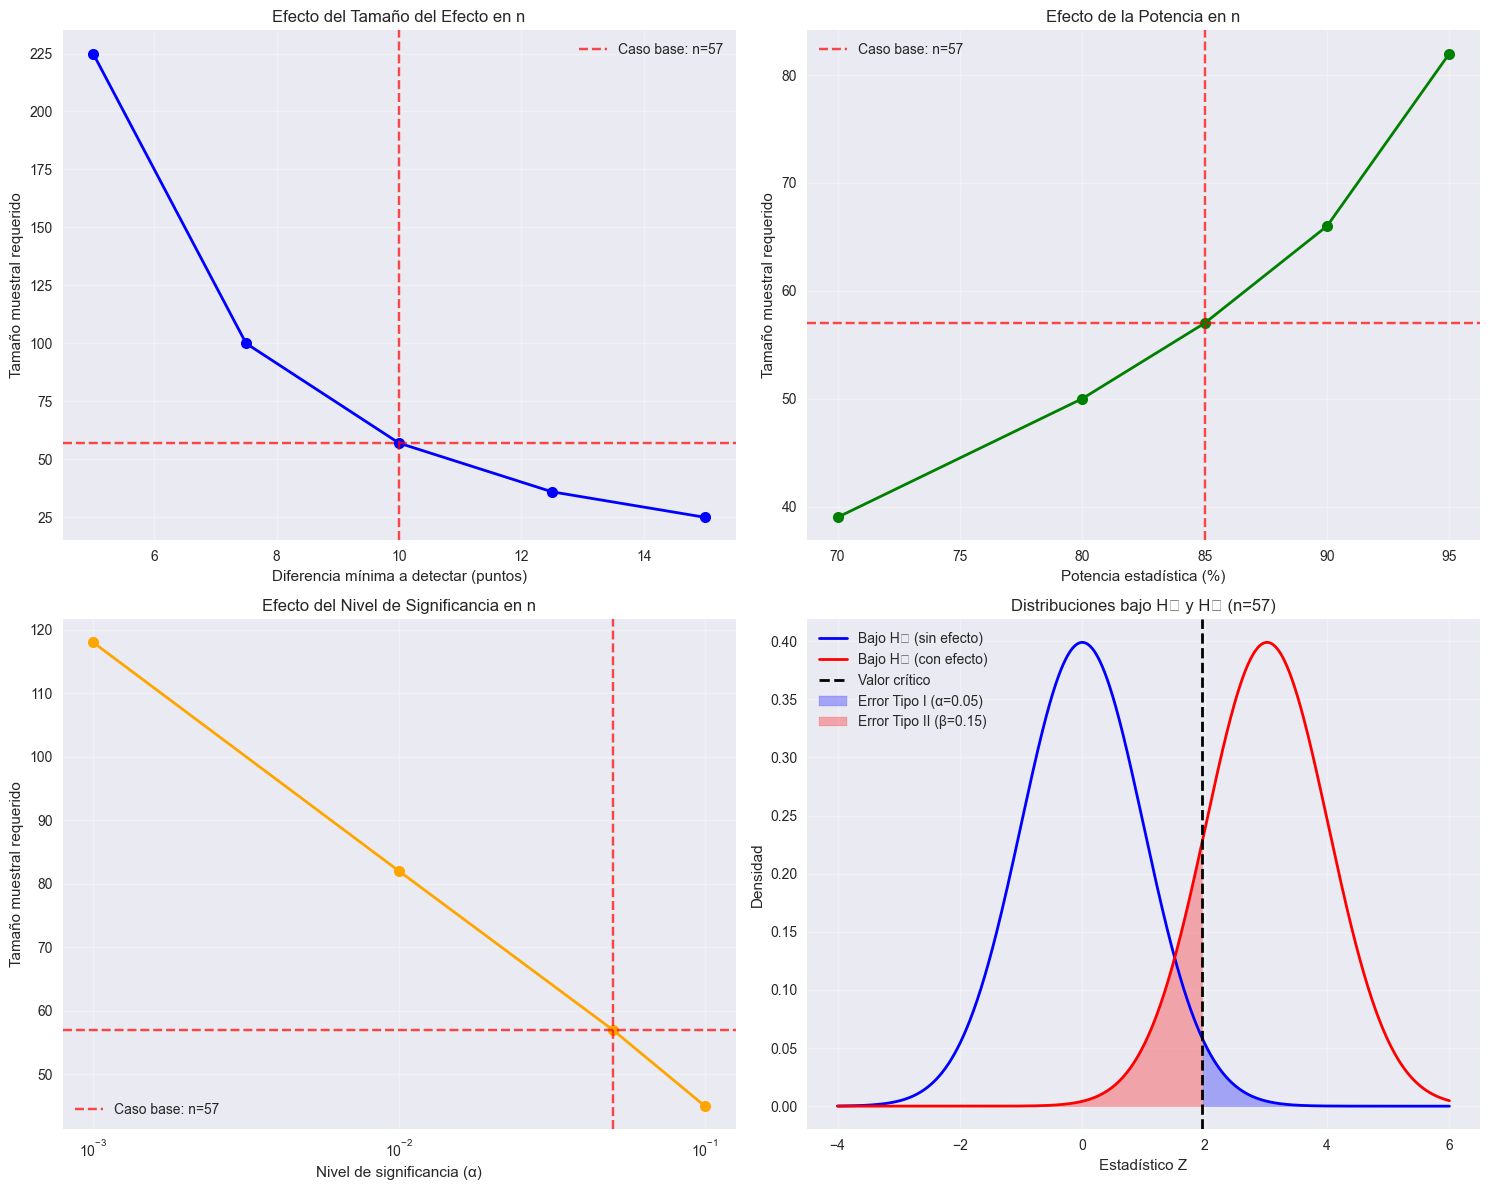

In [22]:
# Visualizaciones
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Efecto del tamaño del efecto
ax1.plot(deltas, ns_delta, 'o-', linewidth=2, markersize=8, color='blue')
ax1.axhline(y=n_required, color='red', linestyle='--', alpha=0.7, label=f'Caso base: n={n_required}')
ax1.axvline(x=delta, color='red', linestyle='--', alpha=0.7)
ax1.set_xlabel('Diferencia mínima a detectar (puntos)')
ax1.set_ylabel('Tamaño muestral requerido')
ax1.set_title('Efecto del Tamaño del Efecto en n')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Gráfico 2: Efecto de la potencia
ax2.plot([p*100 for p in powers], ns_power, 'o-', linewidth=2, markersize=8, color='green')
ax2.axhline(y=n_required, color='red', linestyle='--', alpha=0.7, label=f'Caso base: n={n_required}')
ax2.axvline(x=power*100, color='red', linestyle='--', alpha=0.7)
ax2.set_xlabel('Potencia estadística (%)')
ax2.set_ylabel('Tamaño muestral requerido')
ax2.set_title('Efecto de la Potencia en n')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Gráfico 3: Efecto del nivel de significancia
ax3.plot(alphas, ns_alpha, 'o-', linewidth=2, markersize=8, color='orange')
ax3.axhline(y=n_required, color='red', linestyle='--', alpha=0.7, label=f'Caso base: n={n_required}')
ax3.axvline(x=alpha, color='red', linestyle='--', alpha=0.7)
ax3.set_xlabel('Nivel de significancia (α)')
ax3.set_ylabel('Tamaño muestral requerido')
ax3.set_title('Efecto del Nivel de Significancia en n')
ax3.set_xscale('log')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Gráfico 4: Distribuciones bajo H0 y H1
x = np.linspace(-4, 6, 1000)
y_h0 = stats.norm.pdf(x, 0, 1)  # Bajo H0
y_h1 = stats.norm.pdf(x, delta/(sigma/np.sqrt(n_required)), 1)  # Bajo H1

ax4.plot(x, y_h0, 'b-', linewidth=2, label='Bajo H₀ (sin efecto)')
ax4.plot(x, y_h1, 'r-', linewidth=2, label='Bajo H₁ (con efecto)')
ax4.axvline(z_alpha_2, color='black', linestyle='--', linewidth=2, label='Valor crítico')

# Sombrear áreas
x_alpha = x[x >= z_alpha_2]
y_alpha_h0 = stats.norm.pdf(x_alpha, 0, 1)
ax4.fill_between(x_alpha, y_alpha_h0, alpha=0.3, color='blue', label=f'Error Tipo I (α={alpha})')

x_beta = x[x <= z_alpha_2]
y_beta_h1 = stats.norm.pdf(x_beta, delta/(sigma/np.sqrt(n_required)), 1)
ax4.fill_between(x_beta, y_beta_h1, alpha=0.3, color='red', label=f'Error Tipo II (β={beta:.2f})')

ax4.set_xlabel('Estadístico Z')
ax4.set_ylabel('Densidad')
ax4.set_title(f'Distribuciones bajo H₀ y H₁ (n={n_required})')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
print(f"\n💡 RECOMENDACIONES PRÁCTICAS:")
print(f"   1. El tamaño muestral calculado ({n_required}) es para una muestra")
print(f"      única. Para un diseño con grupo control, necesitarías")
print(f"      aproximadamente {n_required * 2} participantes en total")
print(f"      ({n_required} por grupo).")

print(f"\n   2. CONSIDERACIONES DE ABANDONO (DROPOUT):")
print(f"      • Los estudios longitudinales típicamente tienen 10-20% de abandono")
print(f"      • Para compensar: n_ajustado = n / (1 - tasa_abandono)")
dropout_rates = [0.10, 0.15, 0.20]
for dropout in dropout_rates:
    n_adjusted = int(np.ceil(n_required / (1 - dropout)))
    print(f"      • Con {dropout*100}% abandono: {n_adjusted} participantes por grupo")

print(f"\n   3. OPTIMIZACIÓN DE RECURSOS:")
print(f"      • Si el presupuesto es limitado, considera:")
print(f"        - Reducir la potencia a 80% → n = {ns_power[1]} participantes")
print(f"        - Buscar un efecto mínimo de 12.5 pts → n = {ns_delta[3]} participantes")
print(f"      • Recuerda: menor n = mayor riesgo de no detectar efectos reales")

print(f"\n   4. VALIDACIÓN DEL DISEÑO:")
print(f"      • Considera un estudio piloto con n=20-30 para:")
print(f"        - Validar la variabilidad poblacional (σ = {sigma})")
print(f"        - Estimar tasas de abandono reales")
print(f"        - Refinar protocolos de medición")

print(f"\n   5. ANÁLISIS INTERINO:")
print(f"      • Con n = {n_required}, puedes planificar análisis interinos:")
print(f"        - Al 50% de la muestra (n = {n_required//2}): análisis de futilidad")
print(f"        - Al 75% de la muestra (n = {3*n_required//4}): análisis de eficacia")
print(f"      • Usa métodos de ajuste para comparaciones múltiples")

print(f"\n   6. CONSIDERACIONES METODOLÓGICAS:")
print(f"      • La potencia calculada asume distribución normal")
print(f"      • Para datos no normales, incrementa n en 5-10%")
print(f"      • Considera estratificación por edad/educación para mayor precisión")

print(f"\n   7. INTERPRETACIÓN CLÍNICA:")
print(f"      • Una mejora de {delta} puntos puede ser:")
print(f"        - Estadísticamente significativa con n = {n_required}")
print(f"        - Clínicamente relevante según literatura")
print(f"        - Económicamente justificable según costo-beneficio")

print(f"\n🎯 RESUMEN EJECUTIVO PARA LA DRA. MARTÍNEZ:")
print(f"   ╭─────────────────────────────────────────────╮")
print(f"   │  RECOMENDACIÓN FINAL DEL CONSULTOR          │")
print(f"   ├─────────────────────────────────────────────┤")
print(f"   │  • Muestra por grupo: {n_required} participantes           │")
print(f"   │  • Total del estudio: {n_required * 2} participantes          │")
print(f"   │  • Con 15% abandono: {int(np.ceil(n_required * 2 / 0.85))} participantes total   │")
print(f"   │  • Presupuesto alternativo: {ns_power[1] * 2} total (80% potencia) │")
print(f"   │  • Duración estimada: 18-24 meses           │")
print(f"   ╰─────────────────────────────────────────────╯")

print(f"\n📋 CHECKLIST PRE-ESTUDIO:")
print(f"   ☐ Aprobación comité de ética con n calculado")
print(f"   ☐ Presupuesto ajustado para {int(np.ceil(n_required * 2 / 0.85))} participantes")
print(f"   ☐ Protocolo de randomización definido")
print(f"   ☐ Plan de análisis estadístico registrado")
print(f"   ☐ Criterios de inclusión/exclusión validados")
print(f"   ☐ Sistema de seguimiento de abandonos")
print(f"   ☐ Análisis de potencia actualizado con datos piloto")

print(f"\n🔍 MONITOREO DURANTE EL ESTUDIO:")
print(f"   • Recalcula potencia cada 3 meses con datos reales")
print(f"   • Documenta razones de abandono para futuros estudios")
print(f"   • Mantén cegamiento hasta completar n mínimo")
print(f"   • Prepara análisis de sensibilidad para revisores")


💡 RECOMENDACIONES PRÁCTICAS:
   1. El tamaño muestral calculado (57) es para una muestra
      única. Para un diseño con grupo control, necesitarías
      aproximadamente 114 participantes en total
      (57 por grupo).

   2. CONSIDERACIONES DE ABANDONO (DROPOUT):
      • Los estudios longitudinales típicamente tienen 10-20% de abandono
      • Para compensar: n_ajustado = n / (1 - tasa_abandono)
      • Con 10.0% abandono: 64 participantes por grupo
      • Con 15.0% abandono: 68 participantes por grupo
      • Con 20.0% abandono: 72 participantes por grupo

   3. OPTIMIZACIÓN DE RECURSOS:
      • Si el presupuesto es limitado, considera:
        - Reducir la potencia a 80% → n = 50 participantes
        - Buscar un efecto mínimo de 12.5 pts → n = 36 participantes
      • Recuerda: menor n = mayor riesgo de no detectar efectos reales

   4. VALIDACIÓN DEL DISEÑO:
      • Considera un estudio piloto con n=20-30 para:
        - Validar la variabilidad poblacional (σ = 25)
        - Es

# Consignas

## Consigna 1 – Z-Test - Control de presión arterial en deportistas
El Dr. Roberto Méndez, cardiólogo deportivo del Centro Nacional de Alto Rendimiento, está evaluando un nuevo protocolo de entrenamiento cardiovascular para atletas de élite. Históricamente, los atletas de resistencia que entrenan en este centro han mantenido una presión arterial sistólica promedio de 110 mmHg, con una desviación estándar poblacional bien documentada de 8 mmHg (basada en 15 años de registros médicos).

El nuevo protocolo incluye entrenamientos de alta intensidad intervalica (HIIT) combinados con ejercicios de fuerza. Aunque este método podría mejorar el rendimiento, existe la preocupación teórica de que podría incrementar la presión arterial sistólica debido a la mayor demanda cardiovascular.

Para investigar esta hipótesis, el Dr. Méndez seleccionó aleatoriamente 36 atletas del programa e implementó el nuevo protocolo durante 3 meses. Al finalizar, midió la presión arterial sistólica promedio del grupo, obteniendo 113.5 mmHg.

Objetivo: Determinar si existe evidencia estadística suficiente para concluir que el nuevo protocolo de entrenamiento aumenta la presión arterial sistólica promedio de los atletas. Utiliza un nivel de significancia del 2.5%.

1. Formula las hipótesis nula y alternativa apropiadas
2. ¿Qué tipo de prueba estadística es más adecuada y por qué?
3. Calcula el estadístico de prueba
4. Determina el valor crítico y el p-valor
5. Toma una decisión estadística y formula tu conclusión

In [24]:
import numpy as np
from scipy.stats import norm

# Datos del problema
mu_0 = 110       # Media poblacional histórica (hipótesis nula)
sigma = 8        # Desviación estándar poblacional conocida
n = 36           # Tamaño de muestra
x_bar = 113.5    # Media muestral
alpha = 0.025    # Nivel de significancia

# 1. Estadístico de prueba
z = (x_bar - mu_0) / (sigma / np.sqrt(n))
print("Estadístico de prueba Z:", z)

# 2. Valor crítico (prueba unilateral a la derecha)
z_crit = norm.ppf(1 - alpha)
print("Valor crítico Zα:", z_crit)

# 3. p-valor
p_value = 1 - norm.cdf(z)
print("p-valor:", p_value)

# 4. Decisión
if z > z_crit:
    print("Rechazamos H0: El nuevo protocolo aumenta la presión arterial.")
else:
    print("No se rechaza H0: No hay evidencia suficiente de aumento.")


Estadístico de prueba Z: 2.625
Valor crítico Zα: 1.959963984540054
p-valor: 0.004332448363012609
Rechazamos H0: El nuevo protocolo aumenta la presión arterial.


## Consigna 2 – t de Student - Efectividad de método de estudio digital
La profesora Carla Vázquez del Instituto Tecnológico Regional ha desarrollado una aplicación móvil llamada "StudySmart" que promete optimizar el tiempo de estudio mediante técnicas de aprendizaje espaciado y repetición activa. La app adapta el contenido según el rendimiento individual del estudiante.

Tradicionalmente, los estudiantes de su curso de Cálculo II invierten en promedio 12 horas semanales de estudio individual para aprobar el curso. Sin embargo, no se tiene información histórica sobre la variabilidad de estos tiempos de estudio.

Para evaluar si su aplicación cambia (ya sea aumentando o disminuyendo) el tiempo de estudio necesario, la profesora Vázquez reclutó a 15 estudiantes voluntarios para usar StudySmart durante un semestre completo. Al final del período, registró las horas semanales promedio que cada estudiante dedicó al estudio:

Tiempos registrados (horas/semana):
10.2, 13.8, 11.5, 9.7, 14.1, 12.3, 8.9, 15.2, 11.8, 10.6, 13.4, 9.3, 12.7, 11.1, 10.4

Objetivo: Determinar si existe evidencia estadística de que la aplicación StudySmart modifica significativamente el tiempo de estudio promedio semanal, ya sea aumentándolo o disminuyéndolo. Utiliza un nivel de significancia del 5%.

1. ¿Por qué es apropiado usar una prueba bilateral en este contexto?
2. Formula las hipótesis nula y alternativa
3. ¿Qué distribución estadística debes usar y por qué?
4. Calcula las estadísticas descriptivas de la muestra
5. Calcula el estadístico de prueba y determina el p-valor
6. Toma una decisión estadística y proporciona una recomendación

## Consigna 3 – Cálculo del Tamaño Muestral - Diseño de estudio nutricional infantil
La nutricionista infantil Dra. Elena Morales ha recibido financiamiento del Ministerio de Salud para investigar el impacto de un nuevo suplemento nutricional en el crecimiento de niños en edad escolar (6-8 años). El suplemento, rico en omega-3, zinc y vitamina D, se administraría durante 6 meses.

La variable de interés es el incremento en la estatura (cm) durante el período de estudio. Basándose en estudios previos de crecimiento infantil, la Dra. Morales sabe que:
- La desviación estándar del crecimiento en este grupo etario es de 1.2 cm en 6 meses
- Para que el suplemento sea considerado "nutricionalmente relevante", debe producir un incremento adicional mínimo de 0.8 cm
- El estudio debe comparar el grupo que recibe el suplemento versus un grupo placebo

Los requisitos del comité científico son estrictos:
- Riesgo de error Tipo I: máximo 1%
- Potencia estadística: mínimo 90%
- El estudio debe detectar diferencias en cualquier dirección (el suplemento podría teoricamente también inhibir el crecimiento)

Objetivo: Determinar el tamaño muestral mínimo necesario por grupo (suplemento y placebo) para cumplir con estos requisitos científicos

1. ¿Por qué se requiere una prueba bilateral en este diseño?
2. Identifica los valores críticos necesarios para el cálculo
3. Aplica la fórmula del tamaño muestral paso a paso
4. ¿Cuántos niños se necesitan en total para el estudio?
5. Desafío adicional: Si el presupuesto solo permite reclutar 200 niños en total, ¿qué potencia estadística tendría el estudio? ¿Qué recomendarías?